In [14]:
import numpy as np
from models.zoo import  SersicModel, PSF
import matplotlib.pyplot as plt
from astropy.io import fits

In [15]:
irac_band = "2"
id = 0
kernel_irac = (
    f"/home/matteo/MIRAGE/Simulazioni/simulazioni/kernels/kernel_irac{irac_band}.fits"
)
kernel = fits.open(kernel_irac)[0].data

psf = PSF(kernel)

#### detection

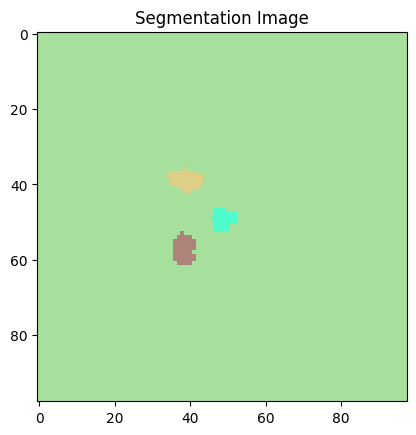

In [16]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
import sep
from photutils.utils import make_random_cmap  # noqa: F401


file_Ks = f"/home/matteo/MIRAGE/Simulazioni/simulazioni/data/{id}/Ks.fits"
# file_irac = "/home/matteo/blind_phoebo/mapper_spitzer/irac1.fits"
file_irac = (
    f"/home/matteo/MIRAGE/Simulazioni/simulazioni/data/{id}/IRAC{irac_band}.fits"
)

# file_rms_irac = f"/home/matteo/MIRAGE/Simulazioni/simulazioni/Sky_IRAC{irac_band}.fits"


cut_irac = fits.open(file_irac)[0].data

cut_Ks = fits.open(file_Ks)[0].data

# creazione dei cutout
# wcs_Ks = WCS(Ks[0].header)

# coordinate centrali del cutout
# coords = SkyCoord(157.58281111724017 ,5.388709222108544, unit="deg")
# coords = SkyCoord(ra, dec, unit="deg")
# dim = u.Quantity(dim_cutout, "arcsec")


# MAPPA DI SEGMENTAZIONES
mean, median, std = sigma_clipped_stats(cut_Ks)

Ks_object, Ks_seg = sep.extract(
    cut_Ks.byteswap().newbyteorder(),
    thresh=median + 2 * std,
    minarea=5,
    segmentation_map=True,
    deblend_cont=1e-4,
    deblend_nthresh=64,
)

plt.imshow(Ks_seg, cmap=make_random_cmap(len(Ks_object) + 1))
plt.title("Segmentation Image")
plt.show()

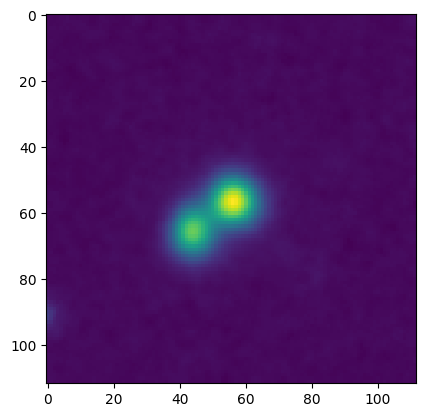

In [17]:
plt.imshow(cut_irac)

In [28]:
my_model = SersicModel(
    x0=55,
    y0=55,
    ellip = 0.2,
    re=200,
    n=4,
    theta=0.5
    
    ) 
my_model.set_parameters_bounds(ellip=(0.1,0.9), n=(0.01,np.inf))
print(my_model)

MODEL NAME: SersicModel 
FREE PARAMS: 7
GRID VARIABLES: ['x', 'y']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             1.00       0          (-inf, inf)         
1    re              200.00     0          (-inf, inf)         
2    n               4.00       0          (0.01, inf)         
3    x0              55.00      0          (-inf, inf)         
4    y0              55.00      0          (-inf, inf)         
5    ellip           0.20       0          (0.10, 0.90)        
6    theta           0.50       0          (-inf, inf)         



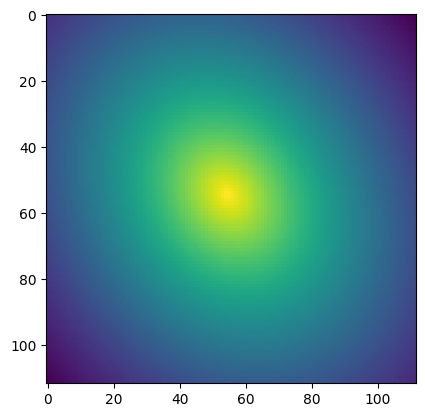

In [26]:
x = np.linspace(0, np.shape(cut_irac)[0], np.shape(cut_irac)[0])
y = np.linspace(0, np.shape(cut_irac)[1], np.shape(cut_irac)[1])
X, Y = np.meshgrid(x, y)



plt.imshow(my_model([X,Y], params={'theta':1, 'n':1}))

  0%|          | 0/500 [00:00<?, ?it/s]

/home/matteo/.pyenv/versions/3.11.6/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 500/500 [00:02<00:00, 205.69it/s]


Text(0.5, 0, 'step number')

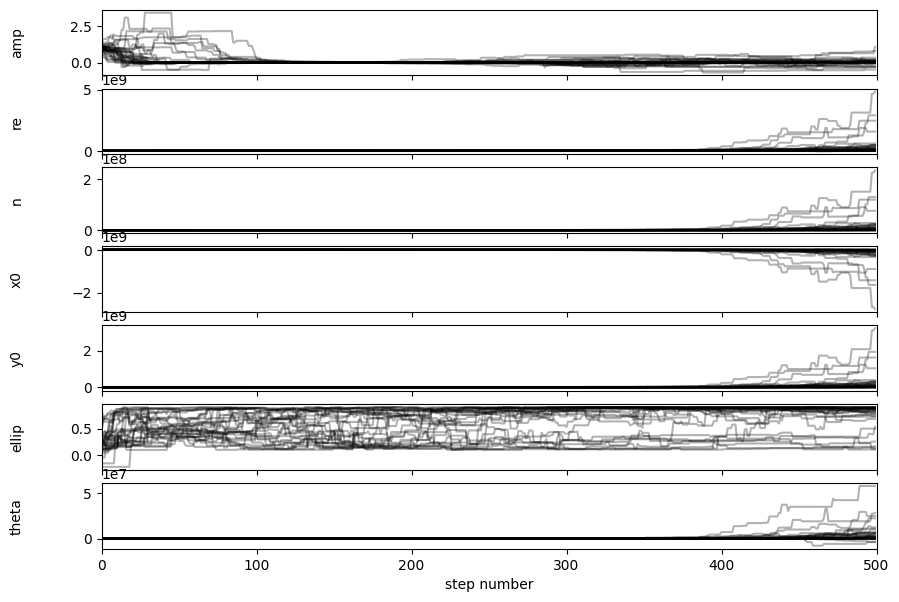

In [29]:
from models.optimizers import MCMC


initial_guess = {
    "amp_0": 14,
    "re_0": 3,
    "n_0": 1.4,
    "x0_0": 64.95,
    "y0_0": 35,
    "ellip_0": 0.2,
    "theta_0": 0.5,
}  # [mu, sigma, A]

initial_guess =  my_model.parameters_values

optimizer = MCMC(model=my_model)


results_composite = optimizer.minimize(
    x0=initial_guess, grid=[X, Y], data=[cut_irac], maxiters=500, walkers_random=0.2
)

fig, axes = plt.subplots(my_model.n_free_parameters, figsize=(10, 7), sharex=True)

samples = results_composite.get_chain()
labels = [p.name for p in my_model.free_parameters]

for i in range(len(initial_guess)):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

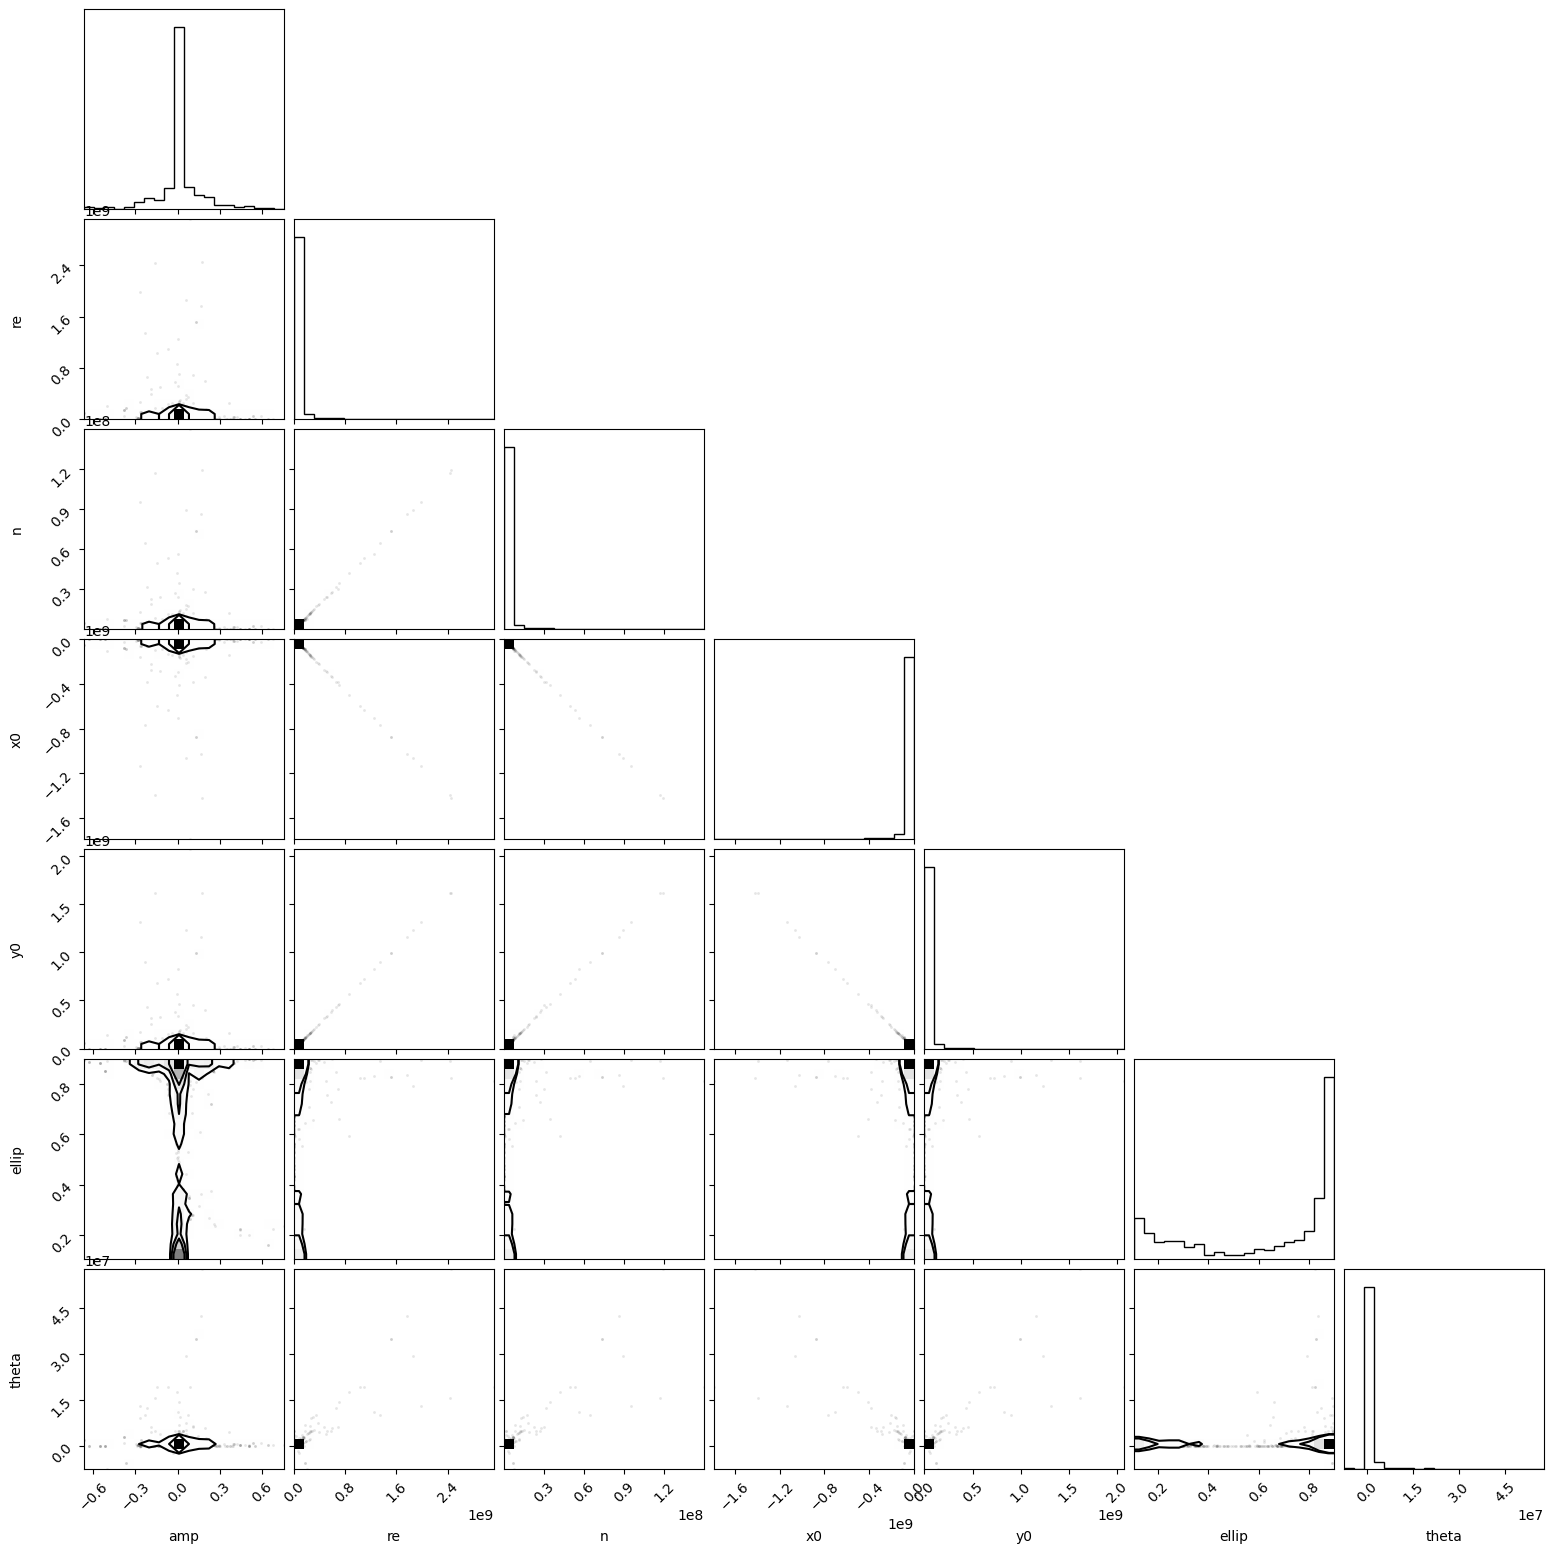

In [30]:
import corner

flat_samples = results_composite.get_chain(discard=100, thin=15, flat=True)

best_results = []
for i in range(len(initial_guess)):
    best_results.append(np.percentile(flat_samples[:, i], [50])[0])
    
fig = corner.corner(flat_samples, labels=labels)

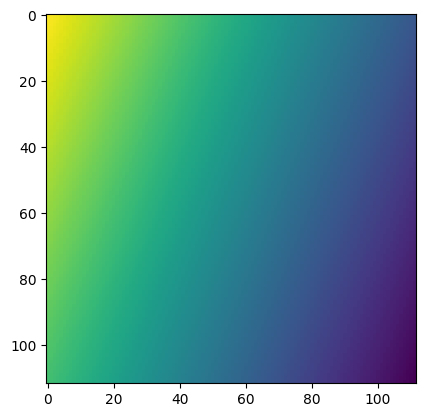

In [32]:
plt.imshow(my_model([X,Y], best_results))